In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import scanpy as sc
import matplotlib.pyplot as plt
from itertools import product

np.set_printoptions(suppress=True)

%reload_ext autoreload
%autoreload 2

In [2]:
adata = sc.read_h5ad('../../datasets/Human_CordBlood/adata_meta.h5ad')
adata

AnnData object with n_obs × n_vars = 24885 × 3462
    obs: 'Timepoint', 'gfp_late', 'GFP', 'Tissue', 'Batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'S_score', 'G2M_score', 'phase', 'label_full', 'label_red', 'clones', 'time_label_full', 'time_label_red', 'Meta clones', 'leiden', 'transferred_labels', 'prediction_score_max', 'dpt_pseudotime', 'def_lab'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'gene_removed'
    uns: 'Batch_colors', 'Timepoint_colors', 'def_lab_colors', 'diffmap_evals', 'final_lab_colors', 'hvg', 'iroot', 'label_full_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'phase_colors', 'pred_corr_colors', 'rank_genes_groups', 'transferred_labels_colors', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'seurat'
    obsp: 'connectivities', 'distances'

<Axes: >

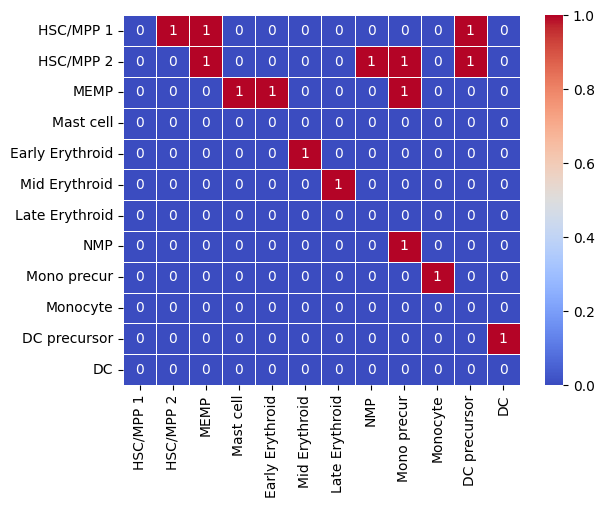

In [2]:
paga = pd.read_csv('paga_transitions.csv', index_col=0)
sns.heatmap(paga, annot=True, linewidth=.5, cmap='coolwarm')
# plt.savefig('./figures/transmap.svg', dpi=300, bbox_inches='tight', transparent=True)

### Pre-processing and filtering

In [6]:
adata.obs['def_lab'] = adata.obs['def_lab'].astype('str')
adata.obs.loc[adata.obs['leiden'] == '7', 'def_lab'] = 'HSC/MPP 2'
adata.obs.loc[adata.obs['def_lab'] == 'HSC_MPP', 'def_lab'] = 'HSC/MPP 1'
adata.obs.loc[adata.obs['def_lab'] == 'DC precursor ', 'def_lab'] = 'DC precursor'

In [7]:
data = pd.read_pickle('../../datasets/Human_CordBlood/CordBlood_Obs_Clones.pkl')
info = data[data.columns[:14]]
clones = data[data.columns[14:]]
clones = clones.fillna(0)
clones = clones.loc[adata.obs_names].copy()

In [5]:
clones

,Clone_1,Clone_2,Clone_3,Clone_4,Clone_5,Clone_6,Clone_7,Clone_8,Clone_9,Clone_10,...,Clone_3931,Clone_3932,Clone_3933,Clone_3934,Clone_3935,Clone_3936,Clone_3937,Clone_3938,Clone_3939,Clone_3940
SITTG7AAATGGACAAATTGGA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SITTG7AAAGTGAAGACATAGT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SITTG7AACCCAAAGGCTGGAT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SITTG7AAAGGATTCATCTATC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SITTG7AAAGGGCGTTGTACGT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SITTB9TTTGACTAGTGGCCTC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SITTB9TTTGGTTCACTTTATC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SITTB9TTTGTTGTCCACTGGG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SITTB9TTTCCTCGTGACCGAA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
adata.obs['Timepoint'] = adata.obs['Timepoint'].astype('str')
adata.obs['time_label_full'] = adata.obs['Timepoint'] + '_' + adata.obs['def_lab']

index = ['Clone_'  + str(np.where(row != 0)[0] + 1)[1:-1] for idx, row in clones.iterrows()]
adata.obs['clones'] = index

In [9]:
rename_cell = adata.obs[adata.obs['time_label_full'] == 'Day17_HSC/MPP 1']

adata.obs.loc[rename_cell.index, 'def_lab'] = rename_cell['transferred_labels'].values
adata.obs.loc[adata.obs['def_lab'] == 'DC2', 'def_lab'] = 'DC'
adata.obs['time_label_full'] = adata.obs['Timepoint'] + '_' + adata.obs['def_lab']

In [8]:
adata.obs

,Timepoint,gfp_late,GFP,Tissue,Batch,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,S_score,...,label_red,clones,time_label_full,time_label_red,Meta clones,leiden,transferred_labels,prediction_score_max,dpt_pseudotime,def_lab
SITTG7AAATGGACAAATTGGA,Day3,,GFP+,CB_HDBI58,CB_HDBI58_Day3_GFP+,5813,43313.0,1398.0,3.227668,0.007405,...,MEMP,Clone_3465,Day3_MEMP,Day3_MEMP,-1.0,26,MEMP,0.494542,0.282089,MEMP
SITTG7AAAGTGAAGACATAGT,Day3,,GFP+,CB_HDBI58,CB_HDBI58_Day3_GFP+,3193,13605.0,692.0,5.086365,-0.167302,...,Mast cell,Clone_3905,Day3_Mast cell,Day3_Mast cell,-1.0,13,Mast cell,1.000000,0.807948,Mast cell
SITTG7AACCCAAAGGCTGGAT,Day3,,GFP+,CB_HDBI58,CB_HDBI58_Day3_GFP+,4508,26535.0,1120.0,4.220840,-0.048952,...,MEMP,Clone_1449,Day3_MEMP,Day3_MEMP,-1.0,3,MEMP,0.475580,0.555401,MEMP
SITTG7AAAGGATTCATCTATC,Day3,,GFP+,CB_HDBI58,CB_HDBI58_Day3_GFP+,3854,16681.0,863.0,5.173551,-0.153677,...,HSC_MPP,Clone_3320,Day3_NMP,Day3_HSC_MPP,-1.0,0,HSC_MPP,0.723462,0.554175,NMP
SITTG7AAAGGGCGTTGTACGT,Day3,,GFP+,CB_HDBI58,CB_HDBI58_Day3_GFP+,4663,26970.0,1517.0,5.624768,0.010442,...,Erythroid,Clone_,Day3_MEMP,Day3_Erythroid,-1.0,3,Early Erythroid,0.416280,0.560456,MEMP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SITTB9TTTGACTAGTGGCCTC,Day17,mid,GFP+,CB_HDBI58,CB_HDBI58_Day17_GFP+mid,2244,15068.0,404.0,2.681179,-0.082700,...,Erythroid,Clone_1964,Day17_Late Erythroid,Day17_Erythroid,5,24,Mid Erythroid,1.000000,0.834377,Late Erythroid
SITTB9TTTGGTTCACTTTATC,Day17,mid,GFP+,CB_HDBI58,CB_HDBI58_Day17_GFP+mid,2474,5719.0,416.0,7.273999,-0.210080,...,Mast cell,Clone_,Day17_Mast cell,Day17_Mast cell,-1.0,13,Mast cell,0.978916,0.979090,Mast cell
SITTB9TTTGTTGTCCACTGGG,Day17,mid,GFP+,CB_HDBI58,CB_HDBI58_Day17_GFP+mid,2575,8349.0,319.0,3.820817,-0.208050,...,Monocyte,Clone_,Day17_Monocyte,Day17_Monocyte,-1.0,1,Neutrophil-myeloid progenitor,0.552055,0.638004,Monocyte
SITTB9TTTCCTCGTGACCGAA,Day17,mid,GFP+,CB_HDBI58,CB_HDBI58_Day17_GFP+mid,1396,3517.0,213.0,6.056298,-0.207592,...,Monocyte,Clone_2672,Day17_Monocyte,Day17_Monocyte,8,8,Monocyte,1.000000,0.775521,Monocyte


In [12]:
del adata.uns['def_lab_colors']

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:843: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:843: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


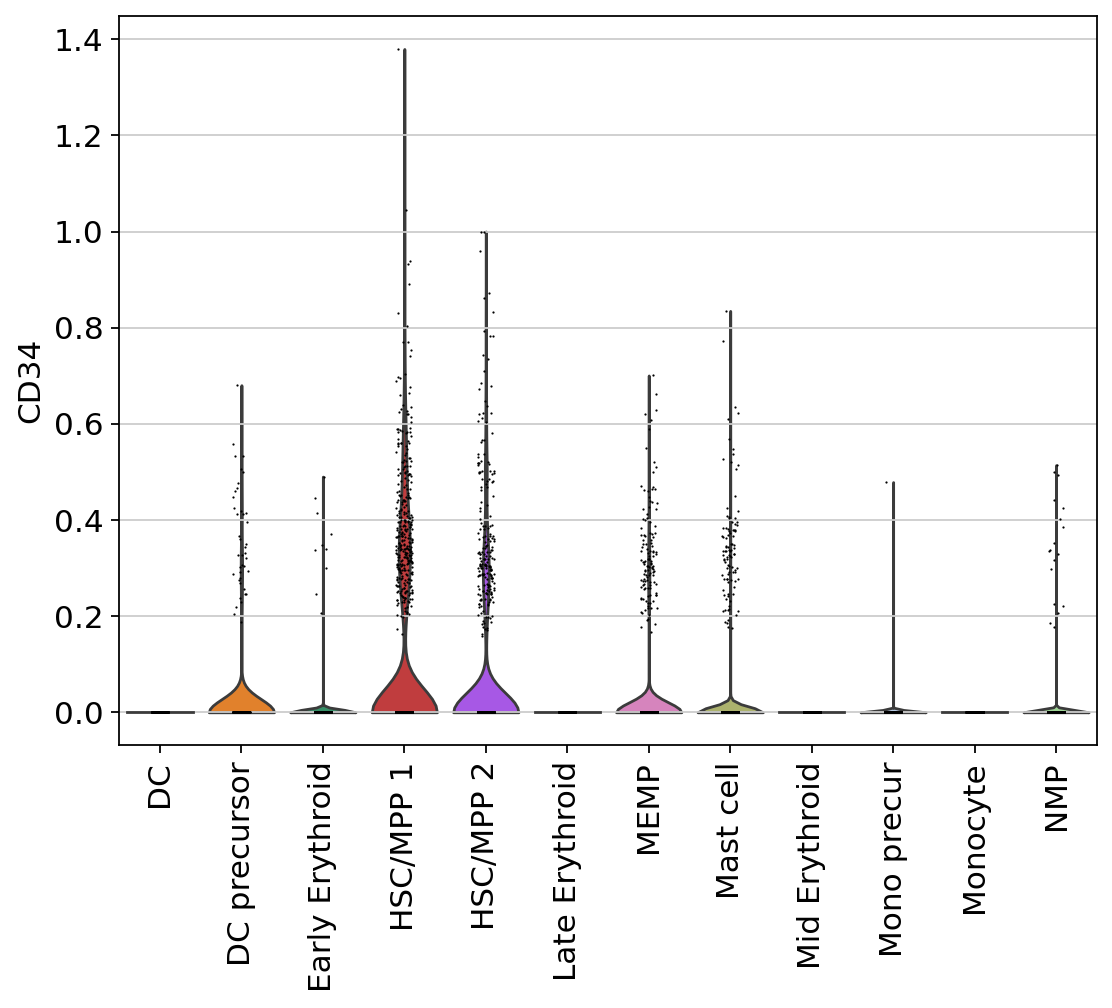

In [19]:
sc.set_figure_params(dpi_save=300, format='svg', figsize=(7, 6), transparent=True)
sc.pl.violin(adata, groupby='def_lab',keys = ['CD34'],rotation = 90)

In [9]:
adata_pos = adata[adata.obs['GFP'] == 'GFP+', :]
adata_neg = adata[adata.obs['GFP'] == 'GFP-', :]
adata_pos_barcode = adata_pos[[item != 'Clone_' for item in list(adata_pos.obs['clones'])], :]

print (adata_pos.shape, adata_neg.shape, adata_pos_barcode.shape)

(16845, 3462) (8040, 3462) (14133, 3462)


### From DNA barcodes to meta-clones

In [10]:
mat = clones.loc[adata_pos_barcode.obs.index.intersection(clones.index)]
mat['time_label_full'] = adata_pos_barcode.obs['time_label_full']
mat.shape

(14133, 3941)

In [11]:
mat = mat.groupby('time_label_full').sum().T
mat.columns.name = ''
mat

,Day10_DC,Day10_DC precursor,Day10_Early Erythroid,Day10_HSC/MPP 1,Day10_HSC/MPP 2,Day10_Late Erythroid,Day10_MEMP,Day10_Mast cell,Day10_Mid Erythroid,Day10_Mono precur,...,Day3_DC,Day3_DC precursor,Day3_Early Erythroid,Day3_HSC/MPP 1,Day3_HSC/MPP 2,Day3_MEMP,Day3_Mast cell,Day3_Mono precur,Day3_Monocyte,Day3_NMP
Clone_1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Clone_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Clone_3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Clone_4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Clone_5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Clone_3936,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
Clone_3937,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
Clone_3938,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0
Clone_3939,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0


In [12]:
mat = sc.AnnData(mat)
sc.pp.filter_cells(mat, min_counts=3)
sc.pp.filter_genes(mat, min_counts=1)
mat

AnnData object with n_obs × n_vars = 606 × 31
    obs: 'n_counts'
    var: 'n_counts'

In [13]:
sc.tl.pca(mat)
sc.pp.neighbors(mat, n_neighbors=15)
sc.tl.umap(mat)
sc.tl.leiden(mat, resolution=1)
sc.tl.rank_genes_groups(mat, 'leiden', method='wilcoxon')

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


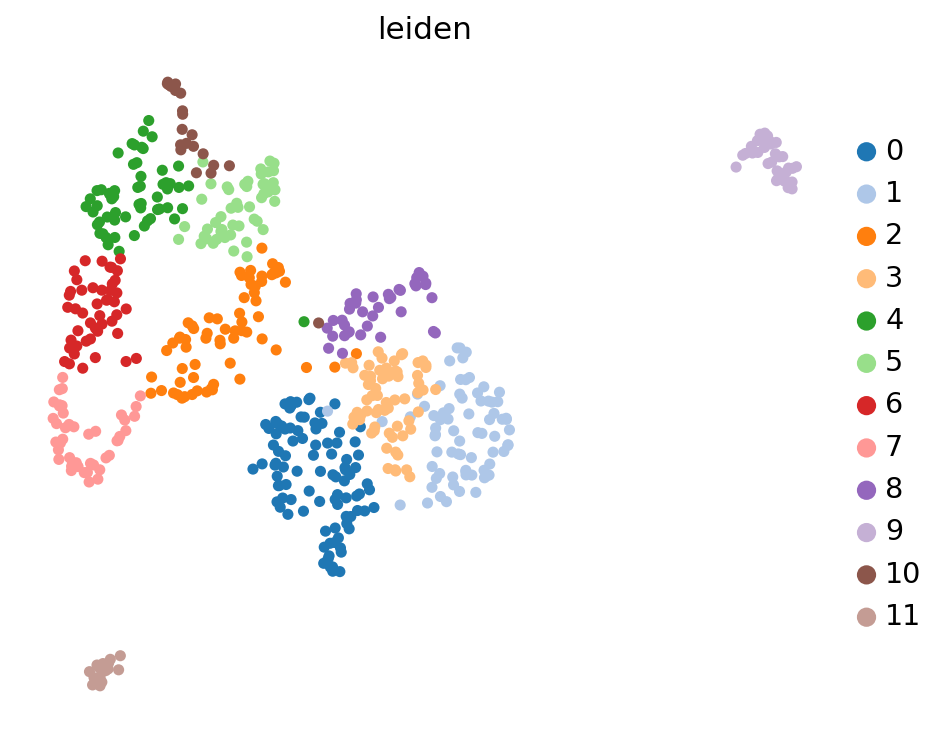

In [14]:
sc.set_figure_params(dpi_save=300, format='svg', figsize=(6, 5), transparent=True)
sc.pl.scatter(
    mat, basis='umap', color='leiden', legend_loc='right margin', size=100, 
    frameon=False, palette=sns.color_palette('tab20')
)

In [15]:
del adata.uns['def_lab_colors']

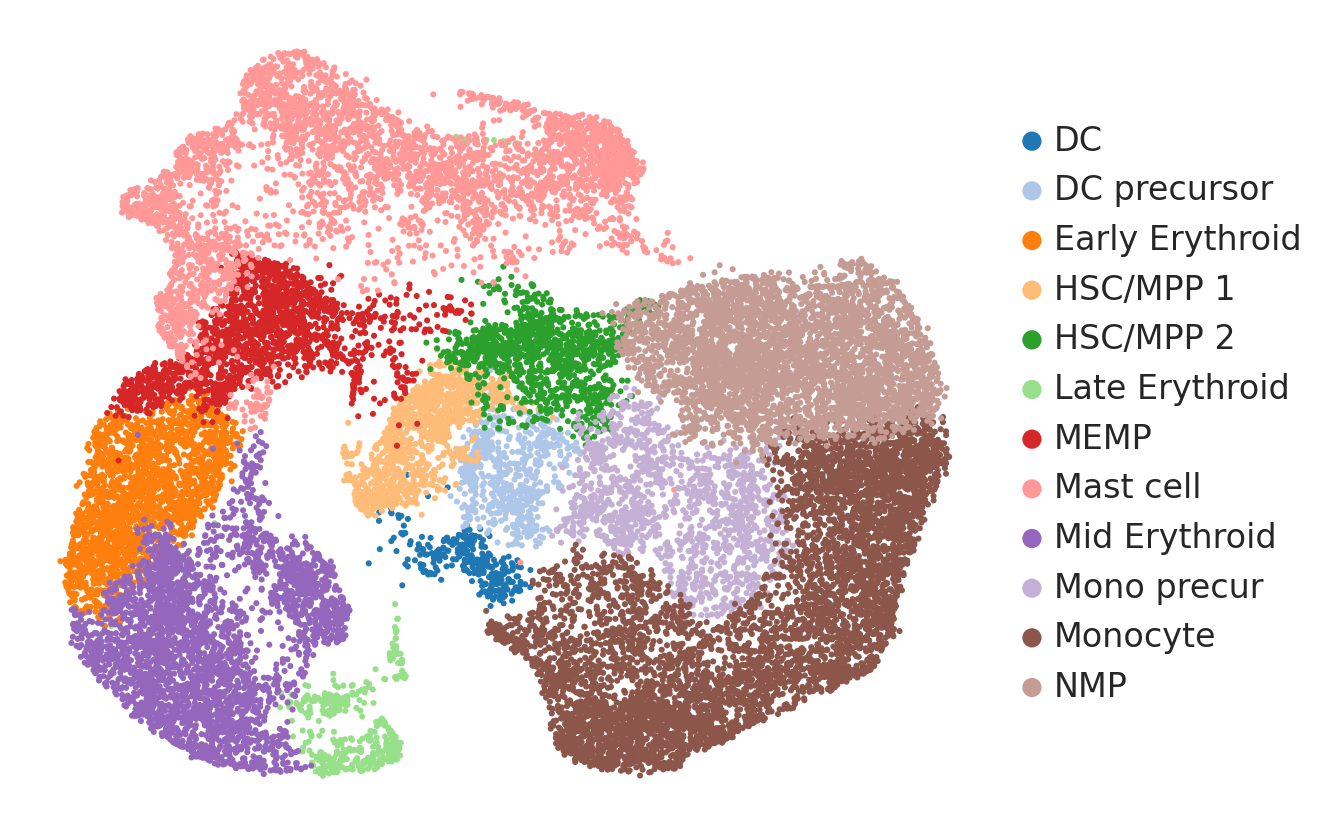

In [26]:
sc.set_figure_params(dpi_save=300, format='svg', figsize=(7, 6), transparent=True)
sc.pl.scatter(adata, basis='umap', color='def_lab', 
              legend_loc='right margin', palette=sns.color_palette('tab20'),
              size=30, frameon=False, title='', legend_fontsize=15)

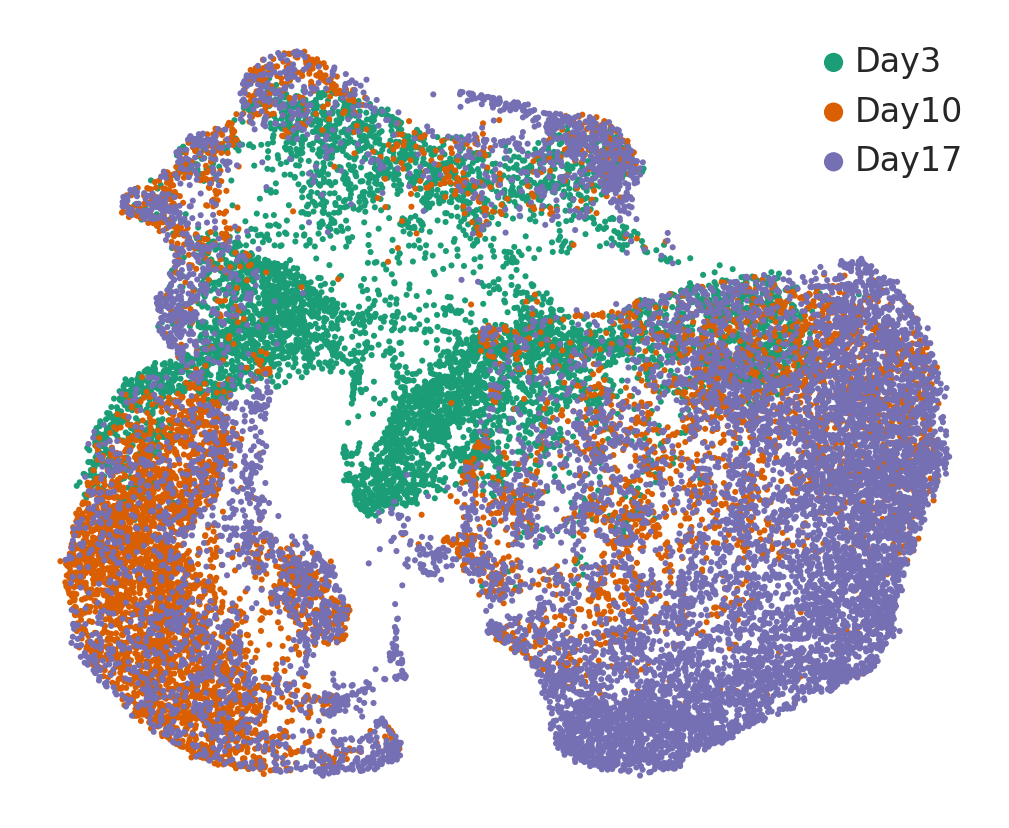

In [27]:
sc.set_figure_params(dpi_save=300, format='svg', figsize=(7, 6), transparent=True)
sc.pl.scatter(adata, basis='umap', color='Timepoint', 
              legend_loc='best', palette=sns.color_palette('Dark2'), 
              size=30, frameon=False, title='', legend_fontsize=15)

In [16]:
adata_pos_barcode

View of AnnData object with n_obs × n_vars = 14133 × 3462
    obs: 'Timepoint', 'gfp_late', 'GFP', 'Tissue', 'Batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'S_score', 'G2M_score', 'phase', 'label_full', 'label_red', 'clones', 'time_label_full', 'time_label_red', 'Meta clones', 'leiden', 'transferred_labels', 'prediction_score_max', 'dpt_pseudotime', 'def_lab'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'gene_removed'
    uns: 'Batch_colors', 'Timepoint_colors', 'def_lab_colors', 'diffmap_evals', 'final_lab_colors', 'hvg', 'iroot', 'label_full_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'phase_colors', 'pred_corr_colors', 'rank_genes_groups', 'transferred_labels_colors', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'seurat'
    obsp: 'connectivities', 'distances'

In [17]:
adata_pos_barcode_filter = adata_pos_barcode[[i in list(mat.obs.index) for i in adata_pos_barcode.obs['clones'].values], :]
adata_pos_barcode_filter

View of AnnData object with n_obs × n_vars = 11064 × 3462
    obs: 'Timepoint', 'gfp_late', 'GFP', 'Tissue', 'Batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'S_score', 'G2M_score', 'phase', 'label_full', 'label_red', 'clones', 'time_label_full', 'time_label_red', 'Meta clones', 'leiden', 'transferred_labels', 'prediction_score_max', 'dpt_pseudotime', 'def_lab'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'gene_removed'
    uns: 'Batch_colors', 'Timepoint_colors', 'diffmap_evals', 'final_lab_colors', 'hvg', 'iroot', 'label_full_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'phase_colors', 'pred_corr_colors', 'rank_genes_groups', 'transferred_labels_colors', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'seurat'
    obsp: 'connectivities', 'distances'

In [18]:
leiden = []
for clone in adata_pos_barcode_filter.obs['clones'].values:
    leiden.append(mat.obs.loc[clone]['leiden'])
adata_pos_barcode_filter.obs['Meta clones'] = leiden

/tmp/ipykernel_2727910/144434872.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_pos_barcode_filter.obs['Meta clones'] = leiden


In [19]:
adata.obs['Meta clones'] = np.zeros(adata.shape[0]) - 1
for i in list(adata_pos_barcode_filter.obs.index):
    adata.obs.at[i, 'Meta clones'] = adata_pos_barcode_filter.obs.loc[i]['Meta clones']
adata.obs['Meta clones'] = [str(i) for i in adata.obs['Meta clones']]

/tmp/ipykernel_2727910/2819564924.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '10' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  adata.obs.at[i, 'Meta clones'] = adata_pos_barcode_filter.obs.loc[i]['Meta clones']


In [20]:
group_labels = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
adata.obs['group'] = pd.Categorical(adata.obs['Meta clones'], categories=group_labels)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


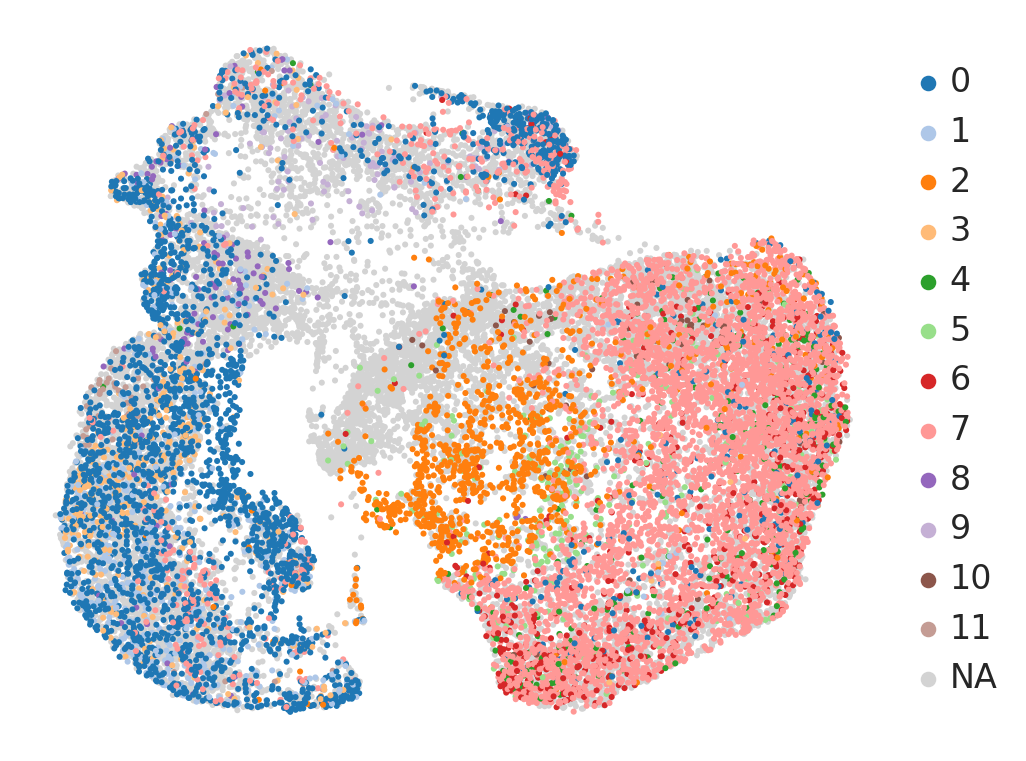

In [33]:
sc.set_figure_params(dpi_save=300, format='svg', figsize=(7, 6), transparent=True)
sc.pl.umap(adata, color=['group'], size=30, legend_loc='right margin', 
           palette=sns.color_palette('tab20'), frameon=False, title='', legend_fontsize=15)

In [21]:
sc.tl.paga(adata, groups='def_lab')

### Generate CLADES inputs (from experimental data)

In [22]:
times = [3, 10, 17]
num_meta_clones = len(set(mat.obs.leiden))
num_times = len(times)
num_pops = len(set(adata_pos_barcode_filter.obs.def_lab))
print (num_meta_clones, num_times, num_pops)

12 3 12


In [23]:
from natsort import natsorted
meta_clones = natsorted(list(set(mat.obs.leiden)))
meta_clones

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']

In [152]:
df = pd.DataFrame(data=mat.X, columns=list(mat.var.index), index=list(mat.obs.index))
df = df.astype('float32')
df.loc[:, df.columns.str.startswith('Day3_')] = df.loc[:, df.columns.str.startswith('Day3_')] * 13284 / 2708
df.loc[:, df.columns.str.startswith('Day10_')] = df.loc[:, df.columns.str.startswith('Day10_')] * 500000 * (13284 / 4428) / 2827
df.loc[:, df.columns.str.startswith('Day17_')] = df.loc[:, df.columns.str.startswith('Day17_')] * 1764225 * (500000 / 460000) * (13284 / 4428) / 11310
df = df.round(0)

/tmp/ipykernel_2518893/3458614449.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[[   0.            0.          530.59780686 ...    0.
     0.            0.        ]
 [   0.            0.          530.59780686 ...    0.
     0.            0.        ]
 [   0.            0.         1061.19561372 ...    0.
     0.            0.        ]
 ...
 [   0.            0.          530.59780686 ...    0.
     0.            0.        ]
 [   0.            0.            0.         ...    0.
     0.            0.        ]
 [   0.            0.            0.         ...    0.
     0.            0.        ]]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df.loc[:, df.columns.str.startswith('Day10_')] = df.loc[:, df.columns.str.startswith('Day10_')] * 500000 * (13284 / 4428) / 2827


In [180]:
anno = pd.read_csv('./annotations.csv')
pops = anno['populations'].values
pops

array(['HSC/MPP 1', 'HSC/MPP 2', 'MEMP', 'Mast cell', 'Early Erythroid',
       'Mid Erythroid', 'Late Erythroid', 'NMP', 'Mono precur',
       'Monocyte', 'DC precursor', 'DC'], dtype=object)

In [154]:
pops = pops[:-1]
pops

array(['HSC/MPP 1', 'HSC/MPP 2', 'MEMP', 'Mast cell', 'Early Erythroid',
       'Mid Erythroid', 'Late Erythroid', 'NMP', 'Mono precur',
       'Monocyte', 'DC precursor', 'DC'], dtype=object)

In [155]:
kinetics = np.zeros((num_meta_clones + 1, num_times, num_pops), dtype=np.float32)

for (idi, meta), (idj, time), (idk, pop) in product(enumerate(meta_clones), enumerate(times), enumerate(pops)):
    if 'Day' + str(time) + '_' + pop in mat.var_names:
        kinetics[idi, idj, idk] = np.array(df[mat.obs.leiden == meta]['Day' + str(time) + '_' + pop].values).sum()

In [156]:
kinetics.sum()

5442561.0

In [157]:
for (idj, time), (idk, pop) in product(enumerate(times), enumerate(pops)):
    if 'Day' + str(time) + '_' + pop in adata.obs['time_label_full'].values:
        num = adata[adata.obs['time_label_full'] == 'Day' + str(time) + '_' + pop, :].shape[0]

        if str(time) == '3':
            num *= (13284 / 2708)
        if str(time) == '10':
            num *= (500000 * (13284 / 4428) / 2827)
        if str(time) == '17':
            num *= (1764225 * (500000 / 460000) * (13284 / 4428) / 11310)
            
        kinetics[-1, idj, idk] = int(num)

In [158]:
kinetics.sum()

14911401.0

### Generate CLADES inputs (initial conditions)

In [159]:
df = pd.crosstab(adata.obs.clones, adata.obs.Timepoint)
df

Timepoint,Day3,Day10,Day17
clones,,,
Clone_,4151,4364,2237
Clone_1,0,6,0
Clone_3,0,4,3
Clone_4,0,1,0
Clone_6,0,5,0
...,...,...,...
Clone_3936,1,0,0
Clone_3937,1,0,0
Clone_3938,3,0,0


In [160]:
vec = np.where(np.count_nonzero(df, 1) == 3)[0]
vec

array([   0,   44,   48,   74,   87,  218,  221,  289,  466,  482,  505,
        507,  554,  562,  572,  610,  625,  631,  758,  860,  905,  906,
        907,  921,  972, 1006, 1021, 1106, 1117, 1129, 1164, 1186, 1235,
       1308, 1439, 1494, 1504, 1509, 1511, 1664, 1726, 1776, 1783, 1855,
       1859, 1885, 1911, 1916, 1921, 1938, 1978, 1994, 1997, 1998, 2002,
       2005, 2048, 2060, 2137, 2210, 2219, 2238, 2360, 2368, 2448, 2460,
       2501, 2539, 2593, 2605, 2607, 2633, 2638, 2748, 2808, 2819, 2823,
       2871, 2911, 2929, 2977, 2988, 3006, 3021, 3055, 3056, 3097, 3100,
       3115, 3154, 3176, 3214])

In [161]:
df = df.iloc[vec].iloc[1:].copy()
df

Timepoint,Day3,Day10,Day17
clones,,,
Clone_55,1,4,56
Clone_59,1,7,15
Clone_89,1,2,1
Clone_103,1,3,3
Clone_284,3,3,2
...,...,...,...
Clone_3783,1,4,5
Clone_3802,2,1,2
Clone_3847,1,2,4


In [162]:
vec = np.isin(adata.obs.clones, df.index)
vec

array([False, False, False, ..., False, False, False])

In [163]:
adata_subset = adata[vec].copy()
adata_subset

AnnData object with n_obs × n_vars = 2053 × 3462
    obs: 'Timepoint', 'gfp_late', 'GFP', 'Tissue', 'Batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'S_score', 'G2M_score', 'phase', 'label_full', 'label_red', 'clones', 'time_label_full', 'time_label_red', 'Meta clones', 'leiden', 'transferred_labels', 'prediction_score_max', 'dpt_pseudotime', 'def_lab'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'gene_removed'
    uns: 'Batch_colors', 'Timepoint_colors', 'def_lab_colors', 'diffmap_evals', 'final_lab_colors', 'hvg', 'iroot', 'label_full_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'phase_colors', 'pred_corr_colors', 'rank_genes_groups', 'transferred_labels_colors', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'seurat'
    obsp: 'connectivities', 'distances'

In [164]:
len(np.unique(adata_subset.obs['clones']))

91

In [165]:
adata_day3 = adata_subset[adata_subset.obs['Timepoint'] == 'Day3'].copy()
adata_day3

AnnData object with n_obs × n_vars = 113 × 3462
    obs: 'Timepoint', 'gfp_late', 'GFP', 'Tissue', 'Batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'S_score', 'G2M_score', 'phase', 'label_full', 'label_red', 'clones', 'time_label_full', 'time_label_red', 'Meta clones', 'leiden', 'transferred_labels', 'prediction_score_max', 'dpt_pseudotime', 'def_lab'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'gene_removed'
    uns: 'Batch_colors', 'Timepoint_colors', 'def_lab_colors', 'diffmap_evals', 'final_lab_colors', 'hvg', 'iroot', 'label_full_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'phase_colors', 'pred_corr_colors', 'rank_genes_groups', 'transferred_labels_colors', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'seurat'
    obsp: 'connectivities', 'distances'

In [166]:
init_con = pd.DataFrame(0, index=anno['clones'].values, columns=pops)
init_con

,HSC/MPP 1,HSC/MPP 2,MEMP,Mast cell,Early Erythroid,Mid Erythroid,Late Erythroid,NMP,Mono precur,Monocyte,DC precursor,DC
Clone 0,0,0,0,0,0,0,0,0,0,0,0,0
Clone 1,0,0,0,0,0,0,0,0,0,0,0,0
Clone 2,0,0,0,0,0,0,0,0,0,0,0,0
Clone 3,0,0,0,0,0,0,0,0,0,0,0,0
Clone 4,0,0,0,0,0,0,0,0,0,0,0,0
Clone 5,0,0,0,0,0,0,0,0,0,0,0,0
Clone 6,0,0,0,0,0,0,0,0,0,0,0,0
Clone 7,0,0,0,0,0,0,0,0,0,0,0,0
Clone 8,0,0,0,0,0,0,0,0,0,0,0,0
Clone 9,0,0,0,0,0,0,0,0,0,0,0,0


In [167]:
init_pops = ['HSC/MPP 1','HSC/MPP 2','MEMP','NMP','Mono precur']
init_pops

['HSC/MPP 1', 'HSC/MPP 2', 'MEMP', 'NMP', 'Mono precur']

In [168]:
df_init_pops = pd.DataFrame(columns=init_pops)
df_init_pops

,HSC/MPP 1,HSC/MPP 2,MEMP,NMP,Mono precur


In [169]:
for meta_clone in adata_day3.obs['Meta clones'].cat.categories:
    adata_day3_meta = adata_day3[adata_day3.obs['Meta clones'] == meta_clone].copy()

    df_temp = pd.crosstab(adata_day3_meta.obs.clones, adata_day3_meta.obs.def_lab)
    df_temp = pd.concat([df_init_pops, df_temp], axis=0).fillna(0)
    df_temp = df_temp[init_pops]
    df_init = np.round(df_temp.sum() / df_temp.sum().sum() * mat.obs.leiden.value_counts()[meta_clone])
    
    for pop in init_pops:
        init_con.loc['Clone ' + meta_clone, pop] = df_init[pop]
        init_con.fillna(0, inplace=True)


/tmp/ipykernel_2518893/3943231128.py:5: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  df_temp = pd.concat([df_init_pops, df_temp], axis=0).fillna(0)
/tmp/ipykernel_2518893/3943231128.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp = pd.concat([df_init_pops, df_temp], axis=0).fillna(0)
/tmp/ipykernel_2518893/3943231128.py:5: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the e

In [170]:
df_temp = pd.crosstab(adata_day3.obs.clones, adata_day3.obs.def_lab)
df_temp = pd.concat([df_init_pops, df_temp], axis=0).fillna(0)
df_temp = df_temp[init_pops]
df_init = np.round(df_temp.sum() / df_temp.sum().sum() * 3247)

for pop in init_pops:
    init_con.loc['Clone BG', pop] = df_init[pop]
    init_con.fillna(0, inplace=True)


/tmp/ipykernel_2518893/1729503974.py:2: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  df_temp = pd.concat([df_init_pops, df_temp], axis=0).fillna(0)
/tmp/ipykernel_2518893/1729503974.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp = pd.concat([df_init_pops, df_temp], axis=0).fillna(0)


In [171]:
init_con

,HSC/MPP 1,HSC/MPP 2,MEMP,Mast cell,Early Erythroid,Mid Erythroid,Late Erythroid,NMP,Mono precur,Monocyte,DC precursor,DC
Clone 0,9.0,6.0,75.0,0,0,0,0,3.0,0.0,0,0,0
Clone 1,0.0,0.0,73.0,0,0,0,0,0.0,0.0,0,0,0
Clone 2,66.0,0.0,0.0,0,0,0,0,0.0,0.0,0,0,0
Clone 3,0.0,0.0,66.0,0,0,0,0,0.0,0.0,0,0,0
Clone 4,4.0,14.0,4.0,0,0,0,0,36.0,0.0,0,0,0
Clone 5,16.0,16.0,0.0,0,0,0,0,16.0,0.0,0,0,0
Clone 6,13.0,21.0,0.0,0,0,0,0,13.0,0.0,0,0,0
Clone 7,26.0,18.0,0.0,0,0,0,0,0.0,0.0,0,0,0
Clone 8,0.0,0.0,39.0,0,0,0,0,0.0,0.0,0,0,0
Clone 9,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0,0,0


In [172]:
kinetics_with_init = np.zeros((num_meta_clones + 1, num_times + 1, num_pops), dtype=np.float32)
kinetics_with_init.shape

(13, 4, 12)

In [173]:
kinetics_with_init[:, 0, :] = init_con.values
kinetics_with_init[:, 1:, :] = kinetics

In [176]:
kinetics_with_init = kinetics_with_init[[0, 1, 2, 3, 4, 5, 6, 7,  8, 10, 12], :, :]
kinetics_with_init.shape

(11, 4, 12)

In [177]:
kinetics_with_init.sum()

14903336.0

In [178]:
np.savetxt('./kinetics_corrected.txt', np.reshape(kinetics_with_init, (11, (num_times + 1) * num_pops)), fmt='%.0f')

### Visualize total cell counts

In [179]:
kinetics_with_init = np.swapaxes(kinetics_with_init, 0, 1)
kinetics_with_init.shape

(4, 11, 12)

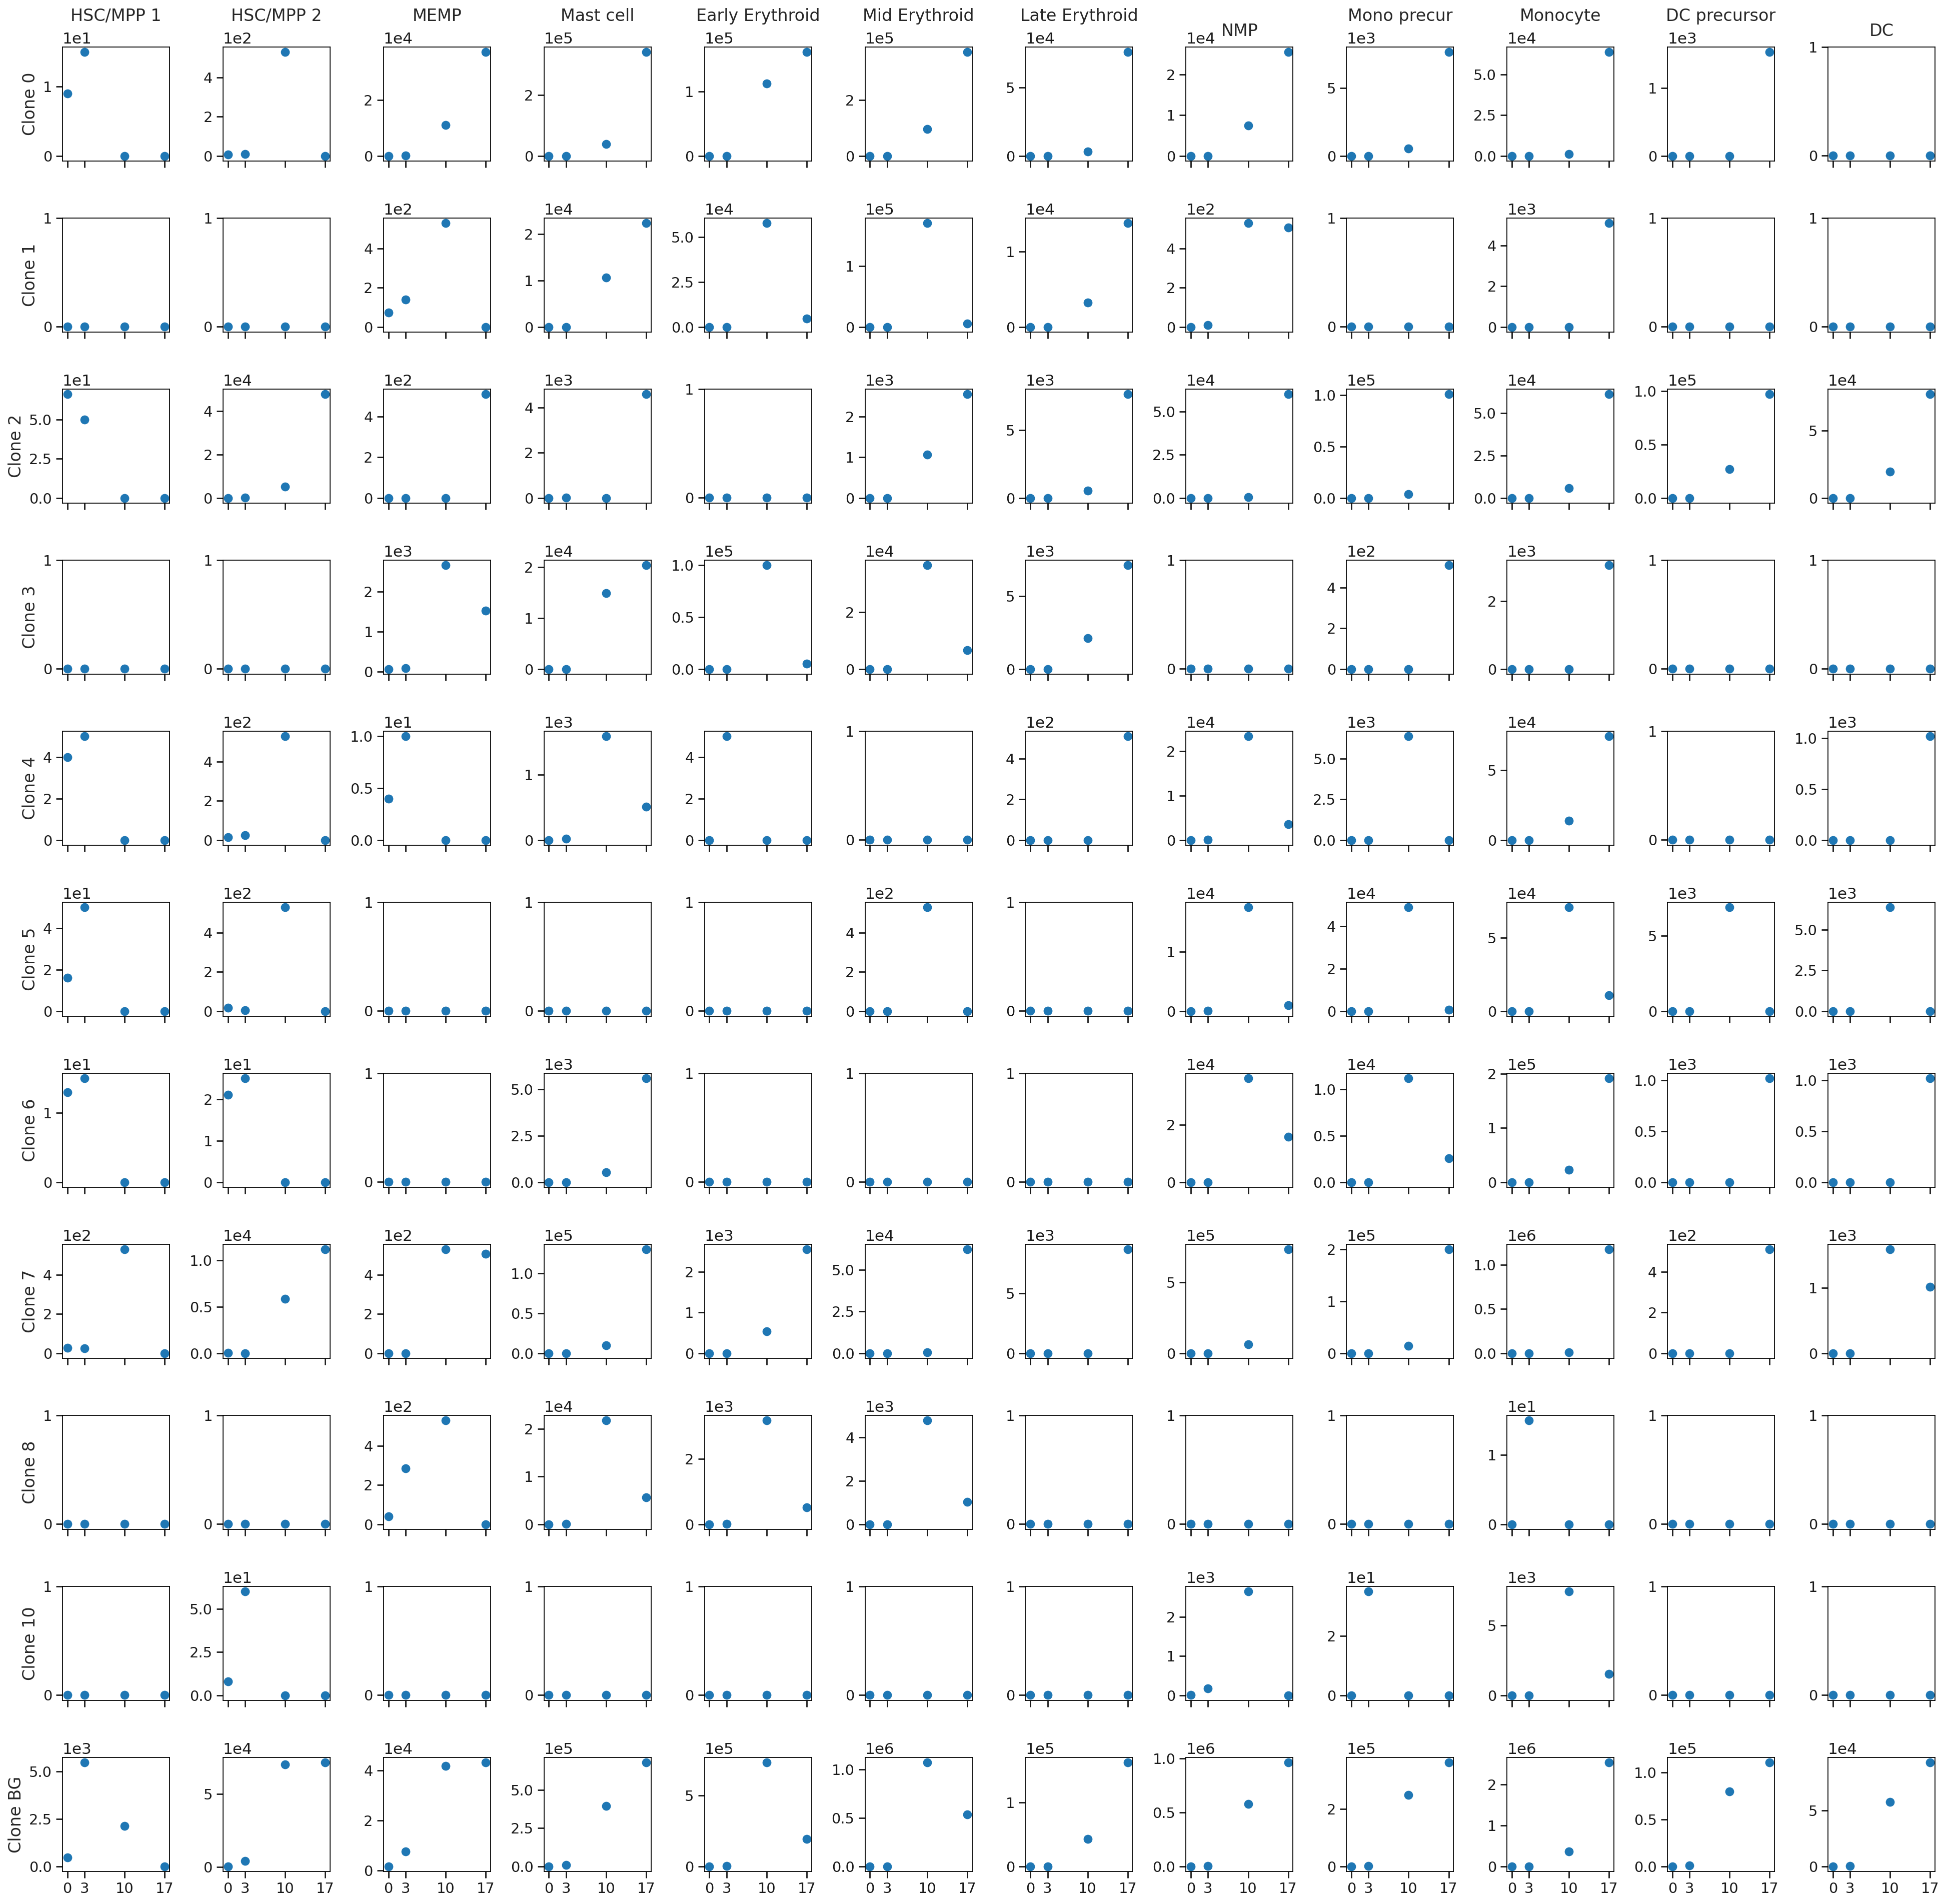

In [185]:
from itertools import product
fig, axes = plt.subplots(kinetics_with_init.shape[1], kinetics_with_init.shape[2], figsize=(30, 30), sharex=True)

anno = pd.read_csv('./annotations.csv')

for row, col in product(range(kinetics_with_init.shape[1]), range(kinetics_with_init.shape[2])):
    axes[row][col].plot(
        [0, 3, 10, 17], 
        kinetics_with_init[:, row, col], 
        marker='o',
        linestyle='',
        markersize=7
    )

    axes[0][col].set_title(anno['populations'][col], fontsize=15, pad=10)
    axes[row][0].set_ylabel(anno['clones'][row], fontsize=15)
    axes[row][col].set_xticks([0, 3, 10, 17])
    axes[row][col].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    axes[row][col].tick_params(axis='both', labelsize=13)
    axes[row][col].grid(visible=False)

    if kinetics_with_init[:, row, col].sum() == 0:
        axes[row][col].set_ylim(-0.05, 1)
        axes[row][col].set_yticks([0, 1])

fig.subplots_adjust(hspace=0.5)
fig.subplots_adjust(wspace=0.5)